This notebook demonstrates how to perform image segmentation using a U-Net architecture. We will download a dataset of pet images and their corresponding segmentation masks, build a simple U-Net model, train it, and then visualize its predictions on new images.

## 1. Data Download

First, we'll download the Oxford-IIIT Pet Dataset, which includes both images and their pixel-level annotations (masks) for segmentation. The images are stored in `images.tar.gz` and the annotations in `annotations.tar.gz`. We'll extract these archives into the current directory.

In [1]:
#downloading the data

!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

--2026-08-25 08:35:31--  http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz [following]
--2026-08-25 08:35:31--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-08-25 08:35:32--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [app

## 2. Data Preparation

We'll define the directories where the images and their trimap masks (segmentation targets) are located. Then, we'll create sorted lists of file paths for both the input images and their corresponding target masks. These lists will ensure that images and masks are paired correctly.

In [2]:
#preparing input file paths & mask file

import os

input_dir = 'images/'
target_dir = 'annotations/trimaps/'

input_img_paths = sorted(
    [os.path.join(input_dir, fname) for fname in os.listdir(input_dir) if fname.endswith(".jpg")]
)
target_paths =sorted(
    [os.path.join(target_dir, fname) for fname in os.listdir(target_dir) if fname.endswith(".png") and not fname.startswith(".")]
)


Let's preview one of the input image paths to ensure our path collection is working correctly.

In [3]:
input_img_paths[9]

'images/Abyssinian_107.jpg'

Before diving into the model, let's visualize an example input image to understand the data we are working with. This helps in sanity-checking our data loading process.

In [4]:
#!pip install tensorflow

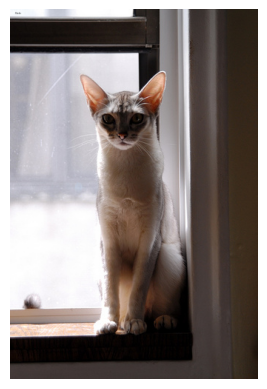

In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

plt.axis("off")
plt.imshow(load_img(input_img_paths[23]))


We define a helper function `display_target` to properly visualize the segmentation masks. The original labels are 1 (background), 2 (pet), and 3 (border). We normalize these to 0, 1, and 2, and then scale them for better visual distinction.

In [6]:
def display_target(target_array):
  #origingal labels are 1,2,3 so we subtract by -1 to make it 0,1,2 and multiply by 127, so 0 is black, 127 is gray and 254 is near white
  normalized_array = (target_array.astype("uint8") -1 ) * 127
  plt.axis("off")
  plt.imshow(normalized_array[:, :, 0])

Now, let's load and display an example target mask. This image shows the ground truth segmentation for an input image, where different colors represent different classes (background, pet, border).

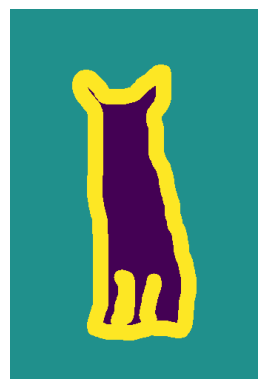

In [7]:
img = img_to_array(load_img(target_paths[23], color_mode="grayscale"))
display_target(img)

This section involves loading all input images and their corresponding target masks into NumPy arrays. We then shuffle these arrays consistently and split them into training and validation sets. This prepares the data for model training.

In [8]:
# loading inputs and targets into two numpy arrays & splitting the arrays into training and validation set

import numpy as np
import random

img_size = (200,200)
num_imgs = len(input_img_paths)

random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
  return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
  img = img_to_array(
      load_img(path, target_size=img_size, color_mode="grayscale"))
  img = img.astype("uint8") - 1
  return img

input_imgs = np.zeros((num_imgs, ) + img_size + (3, ), dtype="float32")
targets = np.zeros((num_imgs, ) + img_size + (1, ), dtype="uint8")
for i in range(num_imgs):
  input_imgs[i] = path_to_input_image(input_img_paths[i])
  targets[i] = path_to_target(target_paths[i])

num_val_samples = 1000
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

## 3. Model Definition

### Defining the model

Here, we define our image segmentation model using the Keras Functional API. The architecture chosen is a U-Net, which is highly effective for segmentation tasks. It consists of an encoder path (downsampling layers) to capture context and a decoder path (upsampling layers) to enable precise localization. The final layer uses a softmax activation for multi-class segmentation.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model(img_size, num_classes):

  inputs = keras.Input(shape=img_size + (3,))
  x = layers.Rescaling(1.0 / 255)(inputs)
  #padding="same" to avoid influence of border padding on feature map size
  x = layers.Conv2D(64, 3, strides = 2, activation="relu", padding="same")(x)
  x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
  x = layers.Conv2D(128, 3, strides = 2, activation="relu", padding="same")(x)
  x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
  x = layers.Conv2D(256, 3, strides = 2, activation="relu", padding="same")(x)
  x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

  x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same", strides=2)(x)
  x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same", strides=2)(x)
  x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same", strides=2)(x)

  outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)
  model = keras.Model(inputs, outputs)
  return model

model = get_model(img_size=img_size, num_classes=3)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 25, 25, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 50, 50, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 100, 100, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 200, 200, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,880,643 (10.99 MB)

 Trainable params: 2,880,643 (10.99 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Training

We compile the model with an `rmsprop` optimizer and `sparse_categorical_crossentropy` loss, suitable for multi-class pixel-wise classification. We then train the model using the prepared training data, with a `ModelCheckpoint` callback to save the best performing model based on validation loss.

In [10]:
model.compile(optimizer = "rmsprop", loss="sparse_categorical_crossentropy")

callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)]

history = model.fit(train_input_imgs, train_targets,
                    epochs=10,
                    batch_size=64,
                    validation_data=(val_input_imgs, val_targets),
                    callbacks=callbacks)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - loss: 0.9381 - val_loss: 0.8854
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 97s 630ms/step - loss: 0.8857 - val_loss: 0.8722
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 617ms/step - loss: 0.8287 - val_loss: 0.8021
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 617ms/step - loss: 0.8152 - val_loss: 0.8065
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 623ms/step - loss: 0.7986 - val_loss: 0.7559
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 622ms/step - loss: 0.7791 - val_loss: 0.7685
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 621ms/step - loss: 0.7603 - val_loss: 0.7673
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 624ms/step - loss: 0.7509 - val_loss: 0.7176
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 622ms/step - loss: 0.7398 - val_loss: 0.7205
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 623ms/step - loss: 0.7177 - val_loss: 0.7226


## 5. Model Evaluation and Prediction

After training, it's crucial to evaluate the model's performance. This section plots the training and validation loss over epochs, which helps in understanding if the model is overfitting or underfitting. A good model will show both losses decreasing and converging.

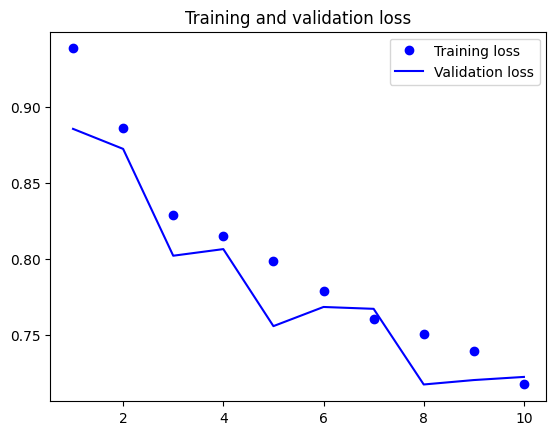

In [11]:
epochs = range(1, len(history.history["loss"]) + 1)
loss = history.history["loss"]
val_loss = history.history["val_loss"]
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Finally, we load the best-trained model and use it to make predictions on a validation image. We then visualize both the input image and the predicted segmentation mask, providing a qualitative assessment of the model's performance. The mask visualizes the segmented regions (background, pet, and border) using a colorbar for clarity.

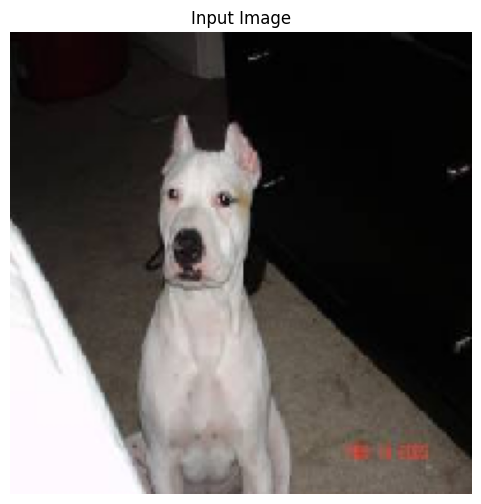

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


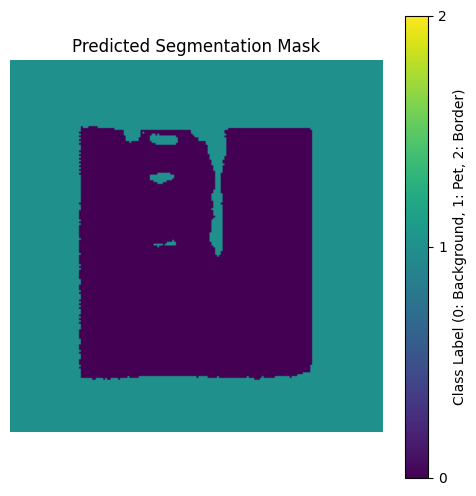

In [12]:
from tensorflow.keras.utils import array_to_img
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

model = keras.models.load_model("oxford_segmentation.keras")

i = 4
test_img = val_input_imgs[i]

# Display the input image
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.imshow(array_to_img(test_img))
plt.title("Input Image")
plt.show()

mask = model.predict(np.expand_dims(test_img, 0))[0]


def display_mask(pred):
  # Argmax along the last axis to get the class index for each pixel
  mask_class = np.argmax(pred, axis=-1)

  # Display the mask with a distinct colormap and colorbar
  plt.figure(figsize=(6, 6))
  plt.axis("off")
  plt.imshow(mask_class, cmap='viridis', vmin=0, vmax=2) # 'viridis' offers good perceptual uniformity
  plt.colorbar(ticks=[0, 1, 2], label='Class Label (0: Background, 1: Pet, 2: Border)')
  plt.title("Predicted Segmentation Mask")
  plt.show()

display_mask(mask)

### Note on Training Epochs

Due to computational constraints, this model was trained for only 10 epochs. In a real-world scenario, running the training for a larger number of epochs (e.g., 20-50 epochs) would likely lead to better segmentation performance and a more refined model. This would allow the model to learn more intricate patterns from the data, resulting in higher accuracy and visual quality of the predicted masks.